# Bob's burger

In [1]:
#setup
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from drawarrow import ax_arrow
from matplotlib import colors
from pypalettes import load_cmap
from pyfonts import load_font

from matplotlib import font_manager
#font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

In [2]:
#load data
transcripts = pd.read_csv("Transcript_Bobs_Burgers_Data_Clean.csv")
imdb_wiki = pd.read_csv("IMDb_Wikipedia_Bobs_Burgers_Data_Clean.csv")

In [3]:
#fill missing
transcripts["dialogue"] = transcripts["dialogue"].fillna("")
transcripts["raw_text"] = transcripts["raw_text"].fillna("")

#count names and words
fart = r'\bfart(?:s|ing|ed)?\b' 
butt = r'\bbutt(?:s)?\b' 
transcripts["fart"] = transcripts["dialogue"].str.lower().apply(lambda x: len(re.findall(fart, x)))
transcripts["farts"] = transcripts["raw_text"].str.lower().apply(lambda x: len(re.findall(fart, x)))
transcripts["butt"] = transcripts["dialogue"].str.lower().apply(lambda x: len(re.findall(butt, x)))
transcripts["Gene"] = transcripts["dialogue"].str.count("Gene")
transcripts["Tina"] = transcripts["dialogue"].str.count("Tina")
transcripts["Bob"] = transcripts["dialogue"].str.count("Bob")
transcripts["Linda"] = transcripts["dialogue"].str.count("Linda")
transcripts["Louise"] = transcripts["dialogue"].str.count("Louise")

#merge word counts with df
strings_df = transcripts.groupby([ "season", "episode"]).agg({"butt": "sum", "fart":"sum", "farts":"sum",
                                                               "Gene": "sum", "Bob": "sum", "Tina": "sum",
                                                                "Louise": "sum",  "Linda": "sum"}).reset_index()
df = pd.merge(imdb_wiki, strings_df, left_on=["season", "episode"], right_on=["season", "episode"], how="left")
df["id"] = df["season"].astype(str) +"-"+ df["episode"].astype(str)

## Data viz

In [4]:
# amend colour palette so that -1 = given background colour
def get_colormap(hex_colors, bg_color, value_range):
    listed_colormap = colors.LinearSegmentedColormap.from_list('colorpalette', hex_colors, N=value_range) 
    bg_color = np.array(colors.to_rgba(bg_color))
    newcolors = listed_colormap(np.linspace(0, 1, value_range))
    cmap_new = colors.ListedColormap(np.vstack((bg_color, newcolors)))
    return cmap_new

#set fonts
title_font = font_manager.FontProperties(fname='C:\\Windows\\Fonts\\KGShakeitOffPopped.ttf')
title_font = font_manager.FontProperties(fname='C:\\Windows\\Fonts\\Amorria-Brush.otf')
font_r = load_font(
  "https://github.com/googlefonts/opensans/blob/main/fonts/ttf/OpenSans-Regular.ttf?raw=true"
)
font_sm = load_font(
  "https://github.com/googlefonts/opensans/blob/main/fonts/ttf/OpenSans-Bold.ttf?raw=true"
)

In [5]:
pivot = df.groupby(["season", "episode"])[["Bob","Tina","Gene",  "Louise","Linda", "fart" , "butt", "farts"]].sum().reset_index()
pivot["last_episode"] = 0
for i in range(0,len(pivot)-1):
    if pivot["season"].iloc[i] != pivot["season"].iloc[i+1]:
        pivot.loc[i, "last_episode"] = 1

# Find indices of last episodes
indices = pivot.index[pivot['last_episode'] == 1].tolist()

# Create empty rows (NaN-filled)
empty_rows = pd.DataFrame([[-1] * len(pivot.columns)] * 3, columns=pivot.columns)

# Loop through indices in reverse order to avoid index shift
for idx in reversed(indices):
    pivot = pd.concat([pivot.iloc[:idx+1], empty_rows, pivot.iloc[idx+1:]]).reset_index(drop=True)

#get first and last episode of a season for annotation
eps_last = [i+ 1 for i in pivot.index[pivot['last_episode'] == 1]] + [len(pivot)]
eps_first = [0]
for i in eps_last[:-1]:
    eps_first.append(i+3)
eps_pair = list(zip(eps_first, eps_last))

#print top butt and fart metrics
total_butt =  int(df["butt"].sum())
print("Total butt mentions", total_butt)
print(pivot.sort_values(by="butt", ascending=False).head(5)[pivot.columns[:-1]])

print("----")
total_fart = int(df["fart"].sum())
print("Total fart mentions", total_fart)
print(pivot.sort_values(by="fart", ascending=False).head(3)[pivot.columns[:-1]])

#transpose for viz
pivot = pivot.transpose()

Total butt mentions 553
     season  episode   Bob  Tina  Gene  Louise  Linda  fart  butt  farts
224      11        2   5.0   9.0  30.0    17.0    7.0   0.0  27.0    0.0
291      13       19   8.0   9.0   9.0     8.0    3.0   1.0  26.0    1.0
164       8       15   5.0  15.0   2.0     3.0    5.0   0.0  20.0    0.0
16        2        1   9.0  15.0  18.0    17.0    1.0   2.0  19.0    2.0
115       6       13  20.0   4.0   5.0     6.0    3.0   1.0  18.0    1.0
----
Total fart mentions 309
     season  episode   Bob  Tina  Gene  Louise  Linda  fart  butt  farts
65        4       12   2.0   8.0   6.0     7.0    2.0  31.0  10.0   31.0
112       6       10   9.0  14.0   0.0    12.0    0.0  19.0   4.0   19.0
233      11       11  25.0   6.0   9.0     0.0    6.0   9.0   3.0    9.0


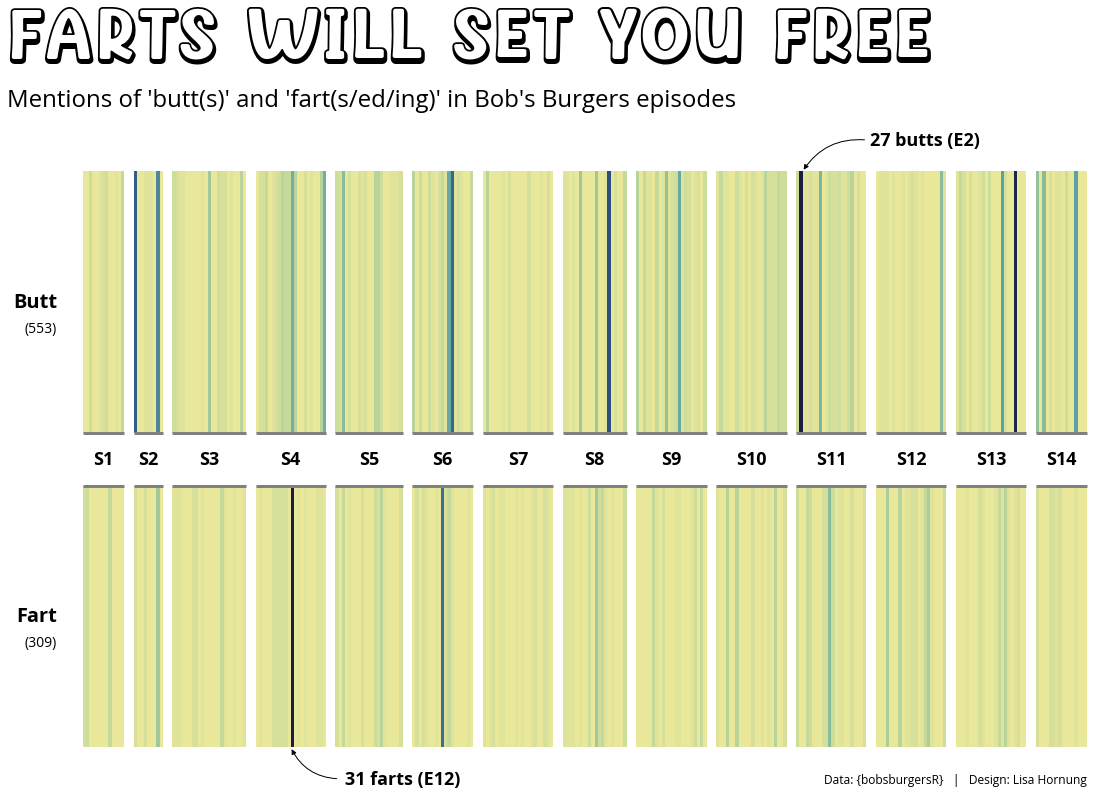

In [7]:
#input parameters ------------------
data = pivot[pivot.index.isin(["butt", "fart"])]
value_range = int(max(data.max()))
bg_color = '#FFFFFF'
hex_colors = load_cmap("Ernst").colors
cmap = get_colormap(hex_colors, bg_color, value_range)

#setup ------------------
fig, axes = plt.subplots(2, 1, figsize=(15,10))
plt.subplots_adjust(hspace=0.2, left=0.07, top=0.85, bottom=0.05, right=1)

#plot data ------------------
for i, index in enumerate(data.index[::-1]):
    sns.heatmap(data[data.index == index], annot=False, fmt=".2f", cmap=cmap, linewidths=0, ax=axes[i], cbar=False)

#format axis ------------------
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].text(-8, 0.5,"Butt", fontsize=20, ha="right", va="center", font=font_sm)
axes[0].text(-8, 0.6,"("+ str(total_butt)+ ")", fontsize=14, ha="right", va="center", font=font_r)
axes[1].text(-8, 0.5,"Fart", fontsize=20, ha="right", va="center", font=font_sm)
axes[1].text(-8, 0.6,"("+ str(total_fart)+ ")", fontsize=14, ha="right", va="center", font=font_r)

#annotations  ------------------
#add season annotation
for i, pair in enumerate(eps_pair):
    axes[0].plot(pair, [1,1], color='grey', linewidth=3, solid_capstyle="butt", clip_on=False)
    axes[1].plot(pair, [0,0], color='grey', linewidth=3, solid_capstyle="butt", clip_on=False)
    text_xpos = (pair[1]-pair[0])/2 + pair[0]
    axes[0].text(text_xpos, 1.1,"S" + str(i+1), fontsize=18, ha="center", va="center", font=font_sm)

#add arrow
ax_arrow(
    ax=axes[1], tail_position=(80, 1.12),
   head_position=(65, 1),
   color="black", width=1, head_width=2, head_length=4,
   radius=-0.3, clip_on=False
)
ax_arrow(
    ax=axes[0],tail_position=(245, -0.12),
   head_position=(225, 0),
   color="black", width=1, head_width=2, head_length=4,
   radius=0.3, clip_on=False
)
axes[0].text(246,-0.12,"27 butts (E2)", fontsize=18, ha="left", va="center", font=font_sm)
axes[1].text(82,1.12,"31 farts (E12)", fontsize=18, ha="left", va="center", font=font_sm)

#title and footer ------------------
plt.figtext(0,1,"FARTS WILL SET YOU FREE", fontsize=65, fontproperties=title_font)
plt.figtext(0,0.94,"Mentions of 'butt(s)' and 'fart(s/ed/ing)' in Bob's Burgers episodes", fontsize=24, font=font_r )
plt.figtext(1,0,"Data: {bobsburgersR}   |   Design: Lisa Hornung", fontsize=12, font=font_r, ha="right")

#save fig ------------------
plt.savefig('2025-day11-bobs-burgers-dialogue-1.png', bbox_inches='tight', pad_inches=1, facecolor="white", dpi=120)
plt.savefig('2025-day11-bobs-burgers-dialogue-1.svg')

plt.show()

## Explore

In [ ]:
# amend colour palette so that -1 = given background colour
def get_colormap(hex_colors, bg_color, value_range):
    listed_colormap = colors.LinearSegmentedColormap.from_list('colorpalette', hex_colors, N=value_range) 
    bg_color = np.array(colors.to_rgba(bg_color))
    newcolors = listed_colormap(np.linspace(0, 1, value_range))
    cmap_new = colors.ListedColormap(np.vstack((bg_color, newcolors)))
    return cmap_new

value_range = int(max(pivot.max()+1))
bg_color = '#FFFFFF'
hex_colors = load_cmap("light_blue_material").colors
cmap = get_colormap(hex_colors, bg_color, value_range)

#plot data
data = pivot.iloc[:-2]

fig, ax = plt.subplots(figsize=(15,8))
sns.heatmap(data, annot=False, cmap=cmap, linewidths=0, ax=ax, cbar=False)
plt.show()

ValueError: Palette with name 'Blues9' not found. Did you mean:
Blues, blues9, Blue, Blues_r, Blues 3?

See available palettes at https://python-graph-gallery.com/color-palette-finder/

In [ ]:
pivot = df.groupby(["season", "episode"])[["Bob","Tina","Gene",  "Louise","Linda", "fart" , "butt"]].sum().reset_index()
#pivot["row"] = 1
#pivot = pivot.drop(columns="id").set_index("row").transpose()

pivot["pos"] = 0
for i in range(1,len(pivot)):
    if pivot["season"].iloc[i] == pivot["season"].iloc[i-1]:
        pivot["pos"].iloc[i] = pivot["pos"].iloc[i-1] + 1
    else:
        pivot["pos"].iloc[i] = pivot["pos"].iloc[i-1] + 3
    
pivot = pivot.drop(columns=["season", "episode"]).set_index("pos").transpose()

In [74]:
df.groupby("season")["episode"].count()

season
1     13
2      9
3     23
4     22
5     21
6     19
7     22
8     20
9     22
10    22
11    22
12    22
13    22
14    16
Name: episode, dtype: int64

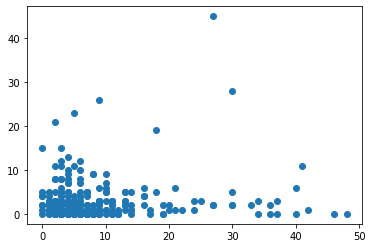

In [67]:
#fart vs ratings
plt.scatter(df["Gene"], df["butt"])

c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Linda', ylabel='rating'>

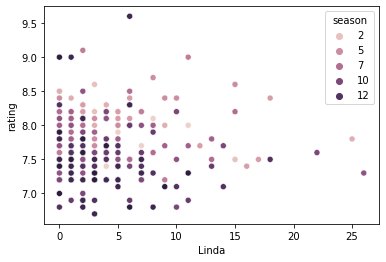

In [81]:
#fart vs ratings
sns.scatterplot(df["Linda"], df["rating"],hue=df["season"])

c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\ana

<AxesSubplot:xlabel='season', ylabel='butt'>

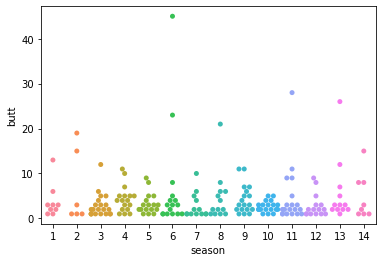

In [97]:
pivot = df[df["butt"]!=0]
sns.swarmplot(y=pivot["butt"],x=pivot["season"])

In [179]:
df[["Bob", "Linda", "Tina", "Louise", "Gene"]].sum()

Bob       3917.0
Linda     1145.0
Tina      2969.0
Louise    1607.0
Gene      2318.0
dtype: float64

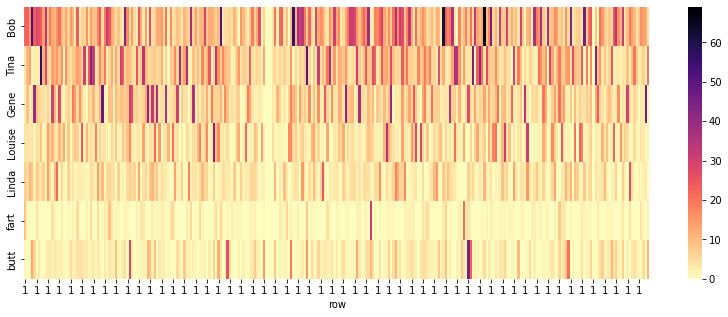

In [180]:
fig, ax = plt.subplots(figsize=(14,5))
sns.heatmap(pivot, annot=False, fmt=".2f", cmap="magma_r", linewidths=0, ax=ax)
plt.show()

In [197]:
pivot = df.groupby("id")[[ "fart" , "butt"]].sum().reset_index()
#pivot["row"] = 1
pivot = pivot.drop(columns="id")
#.set_index("row").transpose()
pivot

,fart,butt
0,9.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,13.0
4,0.0,6.0
...,...,...
270,0.0,1.0
271,4.0,0.0
272,1.0,5.0
273,0.0,0.0


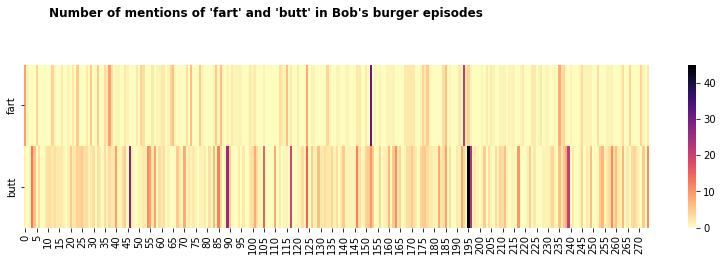

In [202]:
pivot = df.groupby("id")[[ "fart" , "butt"]].sum().reset_index()
pivot["row"] = 1
pivot = pivot.drop(columns="id").set_index("row").transpose()

pivot = df.groupby("id")[[ "fart" , "butt"]].sum().reset_index()
#pivot["row"] = 1
pivot = pivot.drop(columns="id").transpose()

fig, ax = plt.subplots(figsize=(14,3))
sns.heatmap(pivot, annot=False, fmt=".2f", cmap="magma_r", linewidths=0, ax=ax)

fig.set_facecolor("white")
plt.figtext(0.15,1.1, "Number of mentions of 'fart' and 'butt' in Bob's burger episodes", fontsize=12, fontweight="bold", ha="left")
plt.show()

<AxesSubplot:xlabel='episode', ylabel='season'>

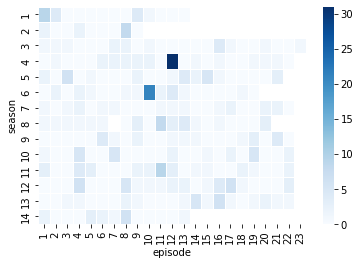

In [112]:
sns.heatmap(df.pivot(index="season", columns="episode", values="fart"), annot=False, fmt=".2f", cmap="Blues", linewidths=0.5)


In [ ]:
sns.heatmap(df.pivot(index="season", columns="episode", values="fart"), annot=False, fmt=".2f", cmap="Blues", linewidths=0.5)

In [117]:
df.pivot(index="season", columns="episode", values="Linda")

episode,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
season,,,,,,,,,,,,,,,,,,,,,
1,7.0,8.0,5.0,4.0,7.0,2.0,15.0,5.0,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,3.0,5.0,3.0,0.0,15.0,3.0,0.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,4.0,2.0,4.0,5.0,5.0,2.0,4.0,1.0,9.0,...,25.0,2.0,0.0,3.0,2.0,3.0,2.0,0.0,7.0,3.0
4,5.0,2.0,12.0,6.0,6.0,17.0,0.0,1.0,2.0,5.0,...,5.0,5.0,16.0,1.0,1.0,5.0,3.0,6.0,18.0,NaN
5,3.0,1.0,4.0,9.0,5.0,4.0,3.0,1.0,0.0,4.0,...,0.0,0.0,3.0,4.0,10.0,15.0,0.0,8.0,NaN,NaN
6,0.0,2.0,2.0,4.0,0.0,2.0,1.0,2.0,9.0,0.0,...,6.0,2.0,1.0,4.0,1.0,11.0,NaN,NaN,NaN,NaN
7,4.0,4.0,3.0,1.0,6.0,2.0,0.0,1.0,6.0,6.0,...,4.0,1.0,4.0,4.0,2.0,15.0,1.0,4.0,8.0,NaN
8,13.0,1.0,8.0,1.0,5.0,6.0,NaN,4.0,2.0,0.0,...,11.0,5.0,11.0,0.0,9.0,7.0,1.0,NaN,NaN,NaN
9,3.0,2.0,1.0,0.0,2.0,1.0,2.0,3.0,0.0,4.0,...,2.0,2.0,7.0,0.0,0.0,7.0,0.0,26.0,5.0,NaN


In [ ]:
df[["Linda", "season"]]

0    Linda      7.0
     season     1.0
1    Linda      8.0
     season     1.0
2    Linda      5.0
               ... 
271  Linda      2.0
     season    14.0
272  season    14.0
273  season    14.0
274  season    14.0
Length: 546, dtype: float64

c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 17.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 15.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\an

<AxesSubplot:xlabel='season', ylabel='Linda'>

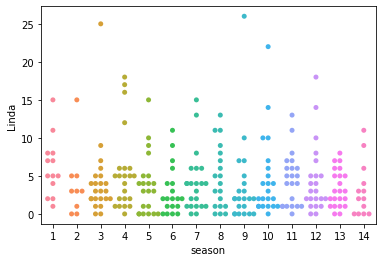

In [93]:
sns.swarmplot(y=df["Linda"],x=df["season"])

In [12]:
transcripts.groupby(["episode", "season"])["count_fart"].sum().unstack()

season,1,2,3,4,5,6,7,8,9,10,11,12,13,14
episode,,,,,,,,,,,,,,
1,9.0,2.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0
2,4.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,2.0,2.0,1.0,0.0,5.0,4.0,6.0,1.0,0.0
5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0
6,0.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,1.0
7,0.0,0.0,1.0,0.0,0.0,0.0,1.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0
8,0.0,7.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0
9,4.0,0.0,0.0,2.0,2.0,0.0,0.0,3.0,2.0,0.0,2.0,1.0,1.0,0.0
